1) COLAB — Load dataset


1.1 Upload (or Drive)


In [1]:
from google.colab import files
uploaded = files.upload()

Saving fifa21 datatset.csv to fifa21 datatset.csv


In [38]:
import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(df.shape)
df.head()

(18979, 77)


/tmp/ipykernel_444/1490113772.py:5: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name)


,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


2) Fix column name issues (your file has ↓OVA)

In [10]:
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={"↓OVA": "OVA"})  # rename target column
print(df.columns.tolist()[:25])

['ID', 'Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Age', 'OVA', 'POT', 'Club', 'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot', 'BOV', 'Best Position', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing']


Set target:


In [11]:
TARGET = "OVA"

Task A — Dataset Understanding


A1) Basic exploration


In [12]:
print("Rows, Columns:", df.shape)
df.info()
display(df.head(3))

Rows, Columns: (18979, 77)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                18979 non-null  int64 
 1   Name              18979 non-null  object
 2   LongName          18979 non-null  object
 3   photoUrl          18979 non-null  object
 4   playerUrl         18979 non-null  object
 5   Nationality       18979 non-null  object
 6   Age               18979 non-null  int64 
 7   OVA               18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Club              18979 non-null  object
 10  Contract          18979 non-null  object
 11  Positions         18979 non-null  object
 12  Height            18979 non-null  object
 13  Weight            18979 non-null  object
 14  Preferred Foot    18979 non-null  object
 15  BOV               18979 non-null  int64 
 16  Best Position     18979 non-nul

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150


A2) Describe


In [13]:
display(df.describe(include="all").T.head(25))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,18979.0,NaN,NaN,NaN,226403.384794,27141.054157,41.0,210135.0,232418.0,246922.5,259216.0
Name,18979,17920,J. Rodríguez,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LongName,18979,18852,Danny Rose,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
photoUrl,18979,18979,https://cdn.sofifa.com/players/252/520/21_60.png,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
playerUrl,18979,18979,http://sofifa.com/player/252520/xiao-zhou/210006/,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nationality,18979,164,England,1705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,18979.0,NaN,NaN,NaN,25.194109,4.71052,16.0,21.0,25.0,29.0,53.0
OVA,18979.0,NaN,NaN,NaN,65.718636,6.968999,47.0,61.0,66.0,70.0,93.0
POT,18979.0,NaN,NaN,NaN,71.136414,6.114635,47.0,67.0,71.0,75.0,95.0
Club,18979,682,No Club,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A3) Data dictionary starter


In [14]:
data_dict = pd.DataFrame({
    "Feature": df.columns,
    "Type (Nominal/Ordinal/Numeric)": "",
    "Description": ""
})
display(data_dict.head(30))

,Feature,Type (Nominal/Ordinal/Numeric),Description
0,ID,,
1,Name,,
2,LongName,,
3,photoUrl,,
4,playerUrl,,
5,Nationality,,
6,Age,,
7,OVA,,
8,POT,,
9,Club,,


In [ ]:
Task B — Data Quality Analysis


B1) Missing values


In [39]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

top10_missing = (pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
                 .query("missing_count > 0")
                 .head(10))

top10_missing

,missing_count,missing_%
Loan Date End,17966,94.662522
Hits,2595,13.673007


,missing_count,missing_%
Loan Date End,17966,94.662522
Hits,2595,13.673007


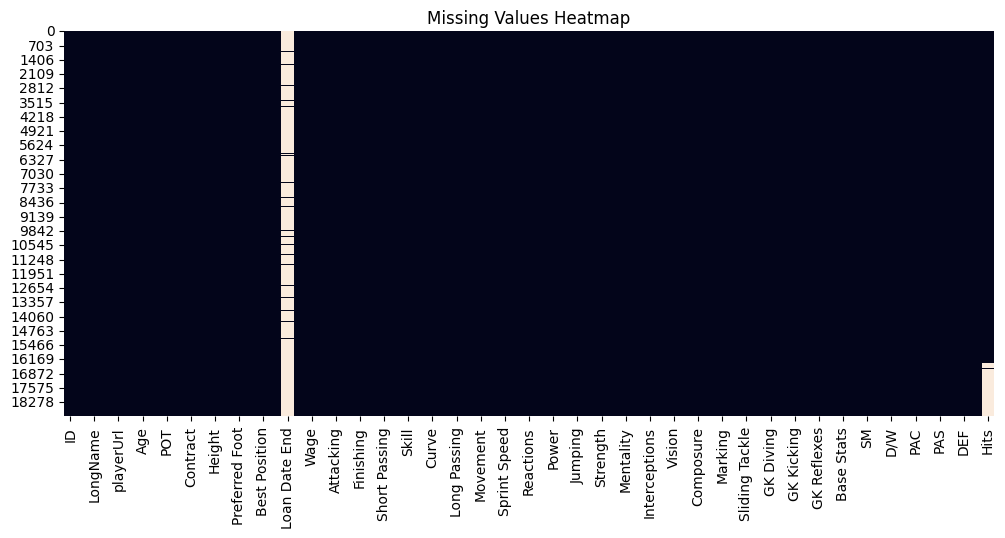

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)
display(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct}).query("missing_count > 0").head(30))

plt.figure(figsize=(12,5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

B2) Duplicates


In [16]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


B3) Noisy values quick checks (examples)


In [17]:
for c in ["Height", "Weight", "Value", "Wage", "Release Clause", "W/F", "SM", "IR", "Hits"]:
    if c in df.columns:
        print(c, "->", df[c].dropna().astype(str).head(5).tolist())

Height -> ['170cm', '187cm', '188cm', '181cm', '175cm']
Weight -> ['72kg', '83kg', '87kg', '70kg', '68kg']
Value -> ['€103.5M', '€63M', '€120M', '€129M', '€132M']
Wage -> ['€560K', '€220K', '€125K', '€370K', '€270K']
Release Clause -> ['€138.4M', '€75.9M', '€159.4M', '€161M', '€166.5M']
W/F -> ['4 ★', '4 ★', '3 ★', '5 ★', '5 ★']
SM -> ['4★', '5★', '1★', '4★', '5★']
IR -> ['5 ★', '5 ★', '3 ★', '4 ★', '5 ★']
Hits -> ['771', '562', '150', '207', '595']


B4) Outliers (numeric)


Numeric columns count: 54


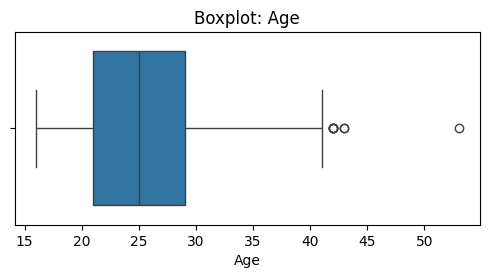

In [42]:
num_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns count:", len(num_cols))

for c in ["OVA", "Age"]:
    if c in df.columns:
        plt.figure(figsize=(6,2.5))
        sns.boxplot(x=df[c])
        plt.title(f"Boxplot: {c}")
        plt.show()

Task C — Data Cleaning (Dataset-specific)


C0) Copy + strip text

In [20]:
df_clean = df.copy()

obj_cols = df_clean.select_dtypes(include="object").columns
for c in obj_cols:
    df_clean[c] = df_clean[c].astype("string").str.strip()

C1) Remove duplicates


In [21]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]
print("Removed duplicates:", before - after)

Removed duplicates: 0


C2) FIFA-specific parsing helpers


In [22]:
import re

def parse_height_cm(x):
    # '179cm' -> 179
    if pd.isna(x): return np.nan
    x = str(x).strip().lower()
    m = re.search(r"(\d+)\s*cm", x)
    return float(m.group(1)) if m else np.nan

def parse_weight_kg(x):
    # '77kg' -> 77
    if pd.isna(x): return np.nan
    x = str(x).strip().lower()
    m = re.search(r"(\d+)\s*kg", x)
    return float(m.group(1)) if m else np.nan

def parse_money_eur(x):
    # '€103.5M' -> 103500000, '€750' -> 750, '€3K' -> 3000, '€0' -> 0
    if pd.isna(x): return np.nan
    x = str(x).strip()
    x = x.replace("€", "").replace(",", "").strip()
    if x == "" or x.lower() == "nan":
        return np.nan
    mult = 1
    if x.endswith("M"):
        mult = 1_000_000
        x = x[:-1]
    elif x.endswith("K"):
        mult = 1_000
        x = x[:-1]
    try:
        return float(x) * mult
    except:
        return np.nan

def parse_stars(x):
    # '4 ★' or '4★' -> 4
    if pd.isna(x): return np.nan
    x = str(x)
    m = re.search(r"(\d+)", x)
    return float(m.group(1)) if m else np.nan

def parse_hits(x):
    # '771' -> 771, '1.6K' -> 1600
    if pd.isna(x): return np.nan
    x = str(x).strip().upper().replace(",", "")
    if x.endswith("K"):
        try:
            return float(x[:-1]) * 1000
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

C3) Apply conversions


In [23]:
# Height/Weight
if "Height" in df_clean.columns:
    df_clean["Height_cm"] = df_clean["Height"].apply(parse_height_cm)
if "Weight" in df_clean.columns:
    df_clean["Weight_kg"] = df_clean["Weight"].apply(parse_weight_kg)

# Money columns
for col in ["Value", "Wage", "Release Clause"]:
    if col in df_clean.columns:
        df_clean[col + "_EUR"] = df_clean[col].apply(parse_money_eur)

# Stars columns
for col in ["W/F", "SM", "IR"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(parse_stars)

# Hits
if "Hits" in df_clean.columns:
    df_clean["Hits"] = df_clean["Hits"].apply(parse_hits)

df_clean[["Height", "Height_cm", "Weight", "Weight_kg"]].head()

,Height,Height_cm,Weight,Weight_kg
0,170cm,170.0,72kg,72.0
1,187cm,187.0,83kg,83.0
2,188cm,188.0,87kg,87.0
3,181cm,181.0,70kg,70.0
4,175cm,175.0,68kg,68.0


C4) Clean inconsistent categorical labels


In [24]:
for col in ["A/W", "D/W", "Preferred Foot", "Best Position"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("string").str.strip().str.title()

C5) Handle missing values (basic justified strategy)


In [25]:
# Drop rows where TARGET is missing (cannot train without target)
df_clean = df_clean.dropna(subset=[TARGET])

# Separate columns
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(exclude=np.number).columns

# Impute numeric -> median, categorical -> mode
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    mode_val = df_clean[c].mode(dropna=True)
    if len(mode_val) > 0:
        df_clean[c] = df_clean[c].fillna(mode_val[0])

df_clean.isna().sum().sort_values(ascending=False).head(15)

,0
ID,0
Name,0
LongName,0
photoUrl,0
playerUrl,0
Nationality,0
Age,0
OVA,0
POT,0
Club,0


Task D — Data Transformation


D1) Feature engineering (good marks)


FE1: BMI


In [26]:
if "Height_cm" in df_clean.columns and "Weight_kg" in df_clean.columns:
    df_clean["Height_m"] = df_clean["Height_cm"] / 100
    df_clean["BMI"] = df_clean["Weight_kg"] / (df_clean["Height_m"] ** 2)

FE2: Value-to-Wage ratio (market indicator)


In [27]:
if "Value_EUR" in df_clean.columns and "Wage_EUR" in df_clean.columns:
    df_clean["Value_to_Wage"] = df_clean["Value_EUR"] / (df_clean["Wage_EUR"] + 1)  # +1 to avoid divide by zero

FE3: Contract length (from "2020 ~ 2024")


In [28]:
def contract_years(x):
    if pd.isna(x): return np.nan
    x = str(x)
    m = re.search(r"(\d{4})\s*~\s*(\d{4})", x)
    if not m:
        return np.nan
    start, end = int(m.group(1)), int(m.group(2))
    return max(end - start, 0)

if "Contract" in df_clean.columns:
    df_clean["Contract_Years"] = df_clean["Contract"].apply(contract_years)
    df_clean["Contract_Years"] = df_clean["Contract_Years"].fillna(df_clean["Contract_Years"].median())

D2) Drop columns that are IDs/URLs (not useful for ML)


In [29]:
drop_cols = [c for c in ["photoUrl", "playerUrl", "Name", "LongName"] if c in df_clean.columns]
df_model = df_clean.drop(columns=drop_cols)
print("Dropped:", drop_cols)
print(df_model.shape)

Dropped: ['photoUrl', 'playerUrl', 'Name', 'LongName']
(18979, 82)


In [36]:
df_model.head()

,ID,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight,...,Hits,Height_cm,Weight_kg,Value_EUR,Wage_EUR,Release Clause_EUR,Height_m,BMI,Value_to_Wage,Contract_Years
0,158023,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,72kg,...,771.0,170.0,72.0,103500000.0,560000.0,138400000.0,1.70,24.913495,184.821099,17.0
1,20801,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187cm,83kg,...,562.0,187.0,83.0,63000000.0,220000.0,75900000.0,1.87,23.735308,286.362335,4.0
2,200389,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188cm,87kg,...,150.0,188.0,87.0,120000000.0,125000.0,159400000.0,1.88,24.615211,959.992320,9.0
3,192985,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181cm,70kg,...,207.0,181.0,70.0,129000000.0,370000.0,161000000.0,1.81,21.366869,348.647706,8.0
4,190871,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,68kg,...,595.0,175.0,68.0,132000000.0,270000.0,166500000.0,1.75,22.204082,488.887078,5.0


D3) Encoding + Scaling with a pipeline (recommended)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 66
Categorical features: 15


Task E — Train/Test Dataset Preparation


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)

X_train.shape, X_test.shape, X_train_p.shape

((15183, 81), (3796, 81), (15183, 5083))

Task F — Final clean dataset export (CSV)


In [32]:
df_model.to_csv("final_clean_fifa21.csv", index=False)
print("Saved: final_clean_fifa21.csv")

Saved: final_clean_fifa21.csv


In [35]:
from google.colab import files
files.download("final_clean_fifa21.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

df.shape: (18979, 77)
df_model.shape: (18979, 82)


,missing_count,missing_%
Loan Date End,17966,94.662522
Hits,2595,13.673007


dup_count: 0


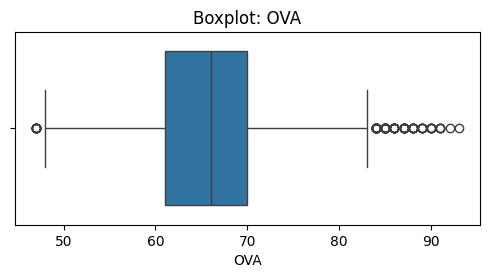

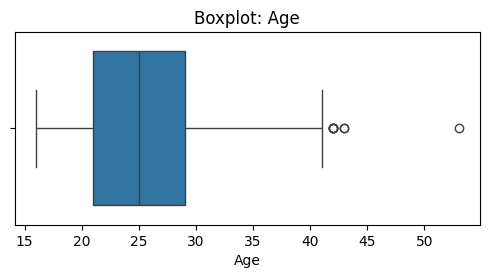

,ID,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight,...,Hits,Height_cm,Weight_kg,Value_EUR,Wage_EUR,Release Clause_EUR,Height_m,BMI,Value_to_Wage,Contract_Years
0,158023,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,72kg,...,771.0,170.0,72.0,103500000.0,560000.0,138400000.0,1.70,24.913495,184.821099,17.0
1,20801,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187cm,83kg,...,562.0,187.0,83.0,63000000.0,220000.0,75900000.0,1.87,23.735308,286.362335,4.0
2,200389,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188cm,87kg,...,150.0,188.0,87.0,120000000.0,125000.0,159400000.0,1.88,24.615211,959.992320,9.0
3,192985,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181cm,70kg,...,207.0,181.0,70.0,129000000.0,370000.0,161000000.0,1.81,21.366869,348.647706,8.0
4,190871,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,68kg,...,595.0,175.0,68.0,132000000.0,270000.0,166500000.0,1.75,22.204082,488.887078,5.0


In [37]:
# =========================
# Report Outputs (for PDF)
# =========================

print("df.shape:", df.shape)
print("df_model.shape:", df_model.shape)

# Top 10 missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)
top10_missing = (pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
                 .query("missing_count > 0")
                 .head(10))
display(top10_missing)

# Duplicate count
dup_count = df.duplicated().sum()
print("dup_count:", dup_count)

# Boxplots: OVA and Age
import seaborn as sns
import matplotlib.pyplot as plt

for c in ["OVA", "Age"]:
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot: {c}")
    plt.show()

# df_model head (5 rows)
display(df_model.head())